<a href="https://colab.research.google.com/github/glygener/colab-notebooks/blob/main/occ_ratio_snv2glycosite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Occurrence ratio of human SNVs relative to predicted and experimental glycosylation sites in GlyGen

The notebook demonstrates how you can use variant and glycosylation site datasets from GlyGen to generate occurrence ratio plots of human non-synonymous germline SNVs and somatic cancer associated SNVs +/−6 amino acids relative to predicted or experiemntally -verified N-linked and O-linked glycosylation sites.

## Step 1. Extract glycosite and variant data from GlyGen datasets

This cell automatically retrieves the latest glycosylation and variant data directly from the GlyGen database and extracts the relevant information needed for the analysis.

###What it does

**Glycosylation sites:** The script queries the GlyGen data release directory to dynamically discover all available human proteoform glycosylation site files. The number of files varies between releases. Each file is streamed line by line directly from GlyGen without being fully downloaded, keeping memory usage low.

Sites are separated into two output files based on their evidence type:
*   `human_glycosites_experimental.csv` — sites with experimental evidence from publications (PubMed or DOI references) or experimental databases
*   `human_glycosites_predicted.csv `— computationally predicted sites or sites without direct experimental evidence

**Missense variants:** Two variant files are streamed from GlyGen and merged into a single output file:
*   Germline variants from `human_protein_mutation_germline_all.csv`
*   Somatic cancer variants from `human_protein_mutation_cancer_all.csv`

Only missense variants are retained — where the reference and alternate amino acids differ at a single position. Each variant is annotated with its type (germline or somatic cancer) and disease association status.

###Output files
All output files are saved to the `data/` folder:
*   `data/human_glycosites_experimental.csv`
*   `data/human_glycosites_predicted.csv`
*   `data/human_variants_missense.csv`

###Note
Because data is streamed directly from GlyGen at runtime, this notebook will always use the most current data release automatically.

In [1]:
import urllib.request
import re
import os
import io

BASE_URL = "https://data.glygen.org/ln2data/releases/data/current/reviewed/"
OUTPUT_DIR = "data"

os.makedirs(OUTPUT_DIR, exist_ok=True)


def get_file_list():
    """Parse the directory listing to find all relevant files dynamically."""
    req = urllib.request.urlopen(BASE_URL)
    html = req.read().decode('utf-8')
    all_files = re.findall(r'href="([^"]+\.csv)"', html)
    glyco_files = [f for f in all_files
                   if f.startswith("human_proteoform_glycosylation_sites_")
                   and ".stat." not in f]
    return glyco_files


def stream_lines(filename):
    """Stream a file line by line directly from the GlyGen URL."""
    url = BASE_URL + filename
    req = urllib.request.urlopen(url)
    for line in io.TextIOWrapper(req, encoding='utf-8'):
        yield line.rstrip('\n')


def extract_glyco_sites(glyco_files):
    """Stream each glycosite file and write experimental/predicted sites."""

    out_file_exp  = os.path.join(OUTPUT_DIR, "human_glycosites_experimental.csv")
    out_file_pred = os.path.join(OUTPUT_DIR, "human_glycosites_predicted.csv")
    FW_exp  = open(out_file_exp,  "w")
    FW_pred = open(out_file_pred, "w")
    header = ["uniprot_canonical_ac", "start_pos", "start_aa", "gtype"]
    FW_exp.write("\"%s\"\n"  % ("\",\"".join(header)))
    FW_pred.write("\"%s\"\n" % ("\",\"".join(header)))

    seen_exp  = set()
    seen_pred = set()

    uniprotkb_filename = "human_proteoform_glycosylation_sites_uniprotkb.csv"
    non_uniprotkb = [f for f in glyco_files if f != uniprotkb_filename]

    # ── Non-UniProtKB files ───────────────────────────────────────────────────
    print("\n=== NON-UNIPROTKB FILES ===")
    for filename in non_uniprotkb:
        if ".stat." in filename:
            continue
        is_predicted = "_predicted_" in filename
        print("%s: %s" % ("PREDICTED" if is_predicted else "EXPERIMENTAL", filename))

        f_list, idx = [], 0
        for line in stream_lines(filename):
            idx += 1
            row = line[1:-1].split("\",\"")
            if idx == 1:
                f_list = row
                continue
            try:
                canon     = row[f_list.index("uniprotkb_canonical_ac")]
                start_pos = row[f_list.index("start_pos")]
                start_aa  = row[f_list.index("start_aa")]
                g_type    = row[f_list.index("glycosylation_type")]
            except (IndexError, ValueError):
                continue
            if canon == "" or start_pos == "":
                continue
            site = "%s:%s:%s:%s" % (canon, start_pos, start_aa, g_type)
            if is_predicted:
                if site not in seen_pred:
                    FW_pred.write("\"%s\"\n" % ("\",\"".join([canon, start_pos, start_aa, g_type])))
                    seen_pred.add(site)
            else:
                if site not in seen_exp:
                    FW_exp.write("\"%s\"\n" % ("\",\"".join([canon, start_pos, start_aa, g_type])))
                    seen_exp.add(site)

    # ── UniProtKB file: first pass to find experimentally supported sites ─────
    print("\n=== UNIPROTKB FILE (pass 1 - finding experimental sites) ===")
    uniprotkb_exp_sites = set()
    f_list, idx = [], 0
    for line in stream_lines(uniprotkb_filename):
        idx += 1
        row = line[1:-1].split("\",\"")
        if idx == 1:
            f_list = row
            continue
        try:
            canon     = row[f_list.index("uniprotkb_canonical_ac")]
            start_pos = row[f_list.index("start_pos")]
            start_aa  = row[f_list.index("start_aa")]
            g_type    = row[f_list.index("glycosylation_type")]
            xref_key  = row[f_list.index("xref_key")]
        except (IndexError, ValueError):
            continue
        if canon == "" or start_pos == "":
            continue
        if "_xref_pubmed" in xref_key or "_xref_doi" in xref_key:
            site = "%s:%s:%s:%s" % (canon, start_pos, start_aa, g_type)
            uniprotkb_exp_sites.add(site)
    print("UniProtKB experimental sites found: %d" % len(uniprotkb_exp_sites))

    # ── UniProtKB file: second pass to write exp or pred ─────────────────────
    print("\n=== UNIPROTKB FILE (pass 2 - writing) ===")
    f_list, idx = [], 0
    for line in stream_lines(uniprotkb_filename):
        idx += 1
        row = line[1:-1].split("\",\"")
        if idx == 1:
            f_list = row
            continue
        try:
            canon     = row[f_list.index("uniprotkb_canonical_ac")]
            start_pos = row[f_list.index("start_pos")]
            start_aa  = row[f_list.index("start_aa")]
            g_type    = row[f_list.index("glycosylation_type")]
        except (IndexError, ValueError):
            continue
        if canon == "" or start_pos == "":
            continue
        site = "%s:%s:%s:%s" % (canon, start_pos, start_aa, g_type)
        if site in uniprotkb_exp_sites:
            if site not in seen_exp:
                FW_exp.write("\"%s\"\n" % ("\",\"".join([canon, start_pos, start_aa, g_type])))
                seen_exp.add(site)
        else:
            if site not in seen_pred:
                FW_pred.write("\"%s\"\n" % ("\",\"".join([canon, start_pos, start_aa, g_type])))
                seen_pred.add(site)

    FW_exp.close()
    FW_pred.close()
    print("\n=== SUMMARY ===")
    print("Total experimental sites written: %d" % len(seen_exp))
    print("Total predicted sites written:    %d" % len(seen_pred))


def extract_variants():
    """Stream variant files and write missense variants."""

    out_file = os.path.join(OUTPUT_DIR, "human_variants_missense.csv")
    FW = open(out_file, "w")
    header = ["uniprot_canonical_ac", "start_pos", "ref_aa", "alt_aa", "variant_type", "disease_status"]
    FW.write("\"%s\"\n" % ("\",\"".join(header)))

    seen = set()
    variant_files = [
        ("human_protein_mutation_germline_all.csv", False),
        ("human_protein_mutation_cancer_all.csv",   True),
    ]

    for filename, is_cancer in variant_files:
        variant_type = "somatic_cancer" if is_cancer else "germline"
        print("Streaming: %s" % filename)
        f_list, idx = [], 0
        for line in stream_lines(filename):
            idx += 1
            row = line[1:-1].split("\",\"")
            if idx == 1:
                f_list = row
                continue
            try:
                canon  = row[f_list.index("uniprotkb_canonical_ac")]
                ref_aa = row[f_list.index("ref_aa")]
                alt_aa = row[f_list.index("alt_aa")]
                if is_cancer:
                    start_pos = int(row[f_list.index("aa_pos")])
                    end_pos   = int(row[f_list.index("aa_pos")])
                    disease_description = row[f_list.index("do_name")]
                    d_status = "yes" if disease_description != "" else "no"
                else:
                    start_pos = int(row[f_list.index("begin_aa_pos")])
                    end_pos   = int(row[f_list.index("end_aa_pos")])
                    do_id  = row[f_list.index("do_id")]
                    mim_id = row[f_list.index("mim_id")]
                    d_status = "no" if do_id == "" and mim_id == "" else "yes"
            except (IndexError, ValueError):
                continue
            if start_pos > 1 and start_pos == end_pos and ref_aa != alt_aa:
                site = "%s:%s:%s>%s:%s" % (canon, start_pos, ref_aa, alt_aa, d_status)
                if site not in seen:
                    newrow = [canon, str(start_pos), ref_aa, alt_aa, variant_type, d_status]
                    FW.write("\"%s\"\n" % ("\",\"".join(newrow)))
                    seen.add(site)
    FW.close()
    print("\n=== SUMMARY ===")
    print("Total missense variants written: %d" % len(seen))


# ── Run both extractions ──────────────────────────────────────────────────────
print("=" * 50)
print("Discovering files from GlyGen...")
print("=" * 50)
glyco_files = get_file_list()
print("Found %d glycosylation site files" % len(glyco_files))

print("\n" + "=" * 50)
print("STEP 1: Extracting glycosylation sites")
print("=" * 50)
extract_glyco_sites(glyco_files)

print("\n" + "=" * 50)
print("STEP 2: Extracting missense variants")
print("=" * 50)
extract_variants()

print("\nAll outputs saved to: %s/" % OUTPUT_DIR)

Discovering files from GlyGen...
Found 26 glycosylation site files

STEP 1: Extracting glycosylation sites

=== NON-UNIPROTKB FILES ===
EXPERIMENTAL: human_proteoform_glycosylation_sites_c_man.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_carbbank.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_diabetes_glycomic.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_embl.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_glycomeatlas.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_glyconnect.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_gptwiki.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_harvard.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_literature.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_literature_mining.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_literature_mining_manually_verified.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_o_gluc.csv
EXPERIMENTAL: human_proteoform_glycosylation_sites_o_g

## 2. Generate mapping files
This cell maps glycosylation sites to nearby missense variants for each combination of glycosylation type and variant type, producing 8 mapping files in total.

###What it does

For each protein, the script cross-references the glycosylation site positions with the variant positions. For each glycosylation site and nearby variant pair, it calculates the relative amino acid position — the distance in amino acids between the variant and the glycosylation site. Only variants within 20 amino acid positions of a glycosylation site (in either direction) are retained.
This produces one mapping file for each combination of:



*   **Glycosylation type:** N-linked, O-linked
*   **Variant type:** germline, somatic cancer
*   **Site type:** experimental, predicted

###Output files
All output files are saved to the `data/` folder:
*  ` data/mapping.human.n_linked.germline_experimental.csv`
*   `data/mapping.human.n_linked.germline_predicted.csv`
*  ` data/mapping.human.n_linked.somatic_cancer_experimental.csv`
*   `data/mapping.human.n_linked.somatic_cancer_predicted.csv`
*   `data/mapping.human.o_linked.germline_experimental.csv`
*   `data/mapping.human.o_linked.germline_predicted.csv`
*   `data/mapping.human.o_linked.somatic_cancer_experimental.csv`
*   `data/mapping.human.o_linked.somatic_cancer_predicted.csv`

In [2]:
import os

__version__ = "1.0"
__status__ = "Dev"

DATA_DIR = "data"


def load_site_dict(in_file, glyco_type):
    tmp_dict = {}
    with open(in_file, "r") as FR:
        f_list, idx = [], 0
        for line in FR:
            idx += 1
            row = line[1:-2].strip().split("\",\"")
            if idx == 1:
                f_list = row
            else:
                gtype = row[f_list.index("gtype")]
                if gtype.lower() != glyco_type.lower():
                    continue
                canon = row[f_list.index("uniprot_canonical_ac")]
                start_pos = int(row[f_list.index("start_pos")])
                site = ":".join(row[2:])
                if canon not in tmp_dict:
                    tmp_dict[canon] = {}
                if start_pos not in tmp_dict[canon]:
                    tmp_dict[canon][start_pos] = {}
                tmp_dict[canon][start_pos][site] = True
    return tmp_dict


def load_var_dict(in_file, v_type):
    tmp_dict = {}
    with open(in_file, "r") as FR:
        f_list, idx = [], 0
        for line in FR:
            idx += 1
            row = line[1:-2].strip().split("\",\"")
            if idx == 1:
                f_list = row
            else:
                canon = row[f_list.index("uniprot_canonical_ac")]
                start_pos = int(row[f_list.index("start_pos")])
                variant_type = row[f_list.index("variant_type")]
                if v_type.lower() != variant_type:
                    continue
                var = ":".join(row[2:])
                if canon not in tmp_dict:
                    tmp_dict[canon] = {}
                if start_pos not in tmp_dict[canon]:
                    tmp_dict[canon][start_pos] = {}
                tmp_dict[canon][start_pos][var] = True
    return tmp_dict


def generate_mapping(glyco_type, v_type, site_type):
    gt = glyco_type.lower().replace("-", "_")
    print("Generating mapping for %s - %s - %s" % (glyco_type, v_type, site_type))

    in_file = os.path.join(DATA_DIR, "human_glycosites_%s.csv" % site_type)
    site_dict = load_site_dict(in_file, glyco_type)

    in_file = os.path.join(DATA_DIR, "human_variants_missense.csv")
    var_dict = load_var_dict(in_file, v_type)

    out_file = os.path.join(DATA_DIR, "mapping.human.%s.%s_%s.csv" % (gt, v_type, site_type))

    newrow = ["uniprot_canonical_ac", "site_pos", "variant_pos", "relative_pos", "site_info", "variant_info"]
    FW = open(out_file, "w")
    FW.write("\"%s\"\n" % ("\",\"".join(newrow)))

    count = 0
    for canon in site_dict:
        if canon not in var_dict:
            continue
        for s_pos in site_dict[canon]:
            for site in site_dict[canon][s_pos]:
                for v_pos in var_dict[canon]:
                    for var in var_dict[canon][v_pos]:
                        diff = s_pos - v_pos
                        if abs(diff) > 20:
                            continue
                        newrow = [canon, str(s_pos), str(v_pos), str(diff), site, var]
                        FW.write("\"%s\"\n" % ("\",\"".join(newrow)))
                        count += 1
    FW.close()
    print("  Saved %d mappings to %s" % (count, out_file))


# automatically generate all 8 datasets
datasets = [
    ("O-linked", "germline",      "experimental"),
    ("O-linked", "germline",      "predicted"),
    ("N-linked", "germline",      "experimental"),
    ("N-linked", "germline",      "predicted"),
    ("O-linked", "somatic_cancer","experimental"),
    ("O-linked", "somatic_cancer","predicted"),
    ("N-linked", "somatic_cancer","experimental"),
    ("N-linked", "somatic_cancer","predicted"),
]

for glyco_type, v_type, site_type in datasets:
    generate_mapping(glyco_type, v_type, site_type)

print("\nAll 8 datasets generated successfully.")

Generating mapping for O-linked - germline - experimental
  Saved 1027550 mappings to data/mapping.human.o_linked.germline_experimental.csv
Generating mapping for O-linked - germline - predicted
  Saved 377321 mappings to data/mapping.human.o_linked.germline_predicted.csv
Generating mapping for N-linked - germline - experimental
  Saved 437935 mappings to data/mapping.human.n_linked.germline_experimental.csv
Generating mapping for N-linked - germline - predicted
  Saved 523259 mappings to data/mapping.human.n_linked.germline_predicted.csv
Generating mapping for O-linked - somatic_cancer - experimental
  Saved 323920 mappings to data/mapping.human.o_linked.somatic_cancer_experimental.csv
Generating mapping for O-linked - somatic_cancer - predicted
  Saved 100353 mappings to data/mapping.human.o_linked.somatic_cancer_predicted.csv
Generating mapping for N-linked - somatic_cancer - experimental
  Saved 151905 mappings to data/mapping.human.n_linked.somatic_cancer_experimental.csv
Generati

## 3. Binomial Statistical Test

This cell runs a two-sided binomial test on each mapping file to determine whether the mutation rate at each relative amino acid position significantly deviates from what would be expected by chance.
###What it does
For each mapping file, the script counts the number of mutations observed at each relative amino acid position. It then tests whether the observed count at each position is significantly different from the expected count, assuming mutations are distributed uniformly across all positions.
The expected probability at each position is defined as 1/n, where n is the total number of positions in the dataset.
P-values are corrected for multiple testing using the Benjamini-Hochberg false discovery rate (FDR) method, which accounts for the fact that multiple positions are being tested simultaneously.

###Output files
One binomial test results file is produced for each mapping file:
*    `data/binomial_test.mapping.human.n_linked.germline_experimental.csv`
*    `data/binomial_test.mapping.human.n_linked.germline_predicted.csv`
*    `data/binomial_test.mapping.human.n_linked.somatic_cancer_experimental.csv`
*    `data/binomial_test.mapping.human.n_linked.somatic_cancer_predicted.csv`
*    `data/binomial_test.mapping.human.o_linked.germline_experimental.csv`
*    `data/binomial_test.mapping.human.o_linked.germline_predicted.csv`
*    `data/binomial_test.mapping.human.o_linked.somatic_cancer_experimental.csv`
*    `data/binomial_test.mapping.human.o_linked.somatic_cancer_predicted.csv`

In [3]:
import os
import glob
import numpy as np
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests

__version__ = "1.0"
__status__ = "Dev"

DATA_DIR = "data"


def load_map_dict(in_file):
    tmp_dict = {}
    with open(in_file, "r") as FR:
        f_list, idx = [], 0
        for line in FR:
            idx += 1
            row = line[1:-2].strip().split("\",\"")
            if idx == 1:
                f_list = row
            else:
                canon    = row[f_list.index("uniprot_canonical_ac")]
                site_pos = int(row[f_list.index("site_pos")])
                var_pos  = int(row[f_list.index("variant_pos")])
                rel_pos  = int(row[f_list.index("relative_pos")])
                cmb = "%s|%s|%s|%s" % (canon, site_pos, var_pos, rel_pos)
                tmp_dict[cmb] = True
    return tmp_dict


def run_binomial_test(in_file):
    print("Processing: %s" % in_file)
    map_dict = load_map_dict(in_file)
    count_dict = {}
    N = 0
    for cmb in map_dict:
        rel_pos = int(cmb.split("|")[-1])
        if rel_pos not in count_dict:
            count_dict[rel_pos] = 0
        count_dict[rel_pos] += 1
        N += 1

    # null probability: uniform across all relative_pos values observed in this file
    p = 1.0 / float(len(count_dict.keys()))

    # calculate all raw p-values first
    positions = []
    k_values = []
    p_values = []
    for rel_pos in sorted(count_dict):
        k = count_dict[rel_pos]
        p_value = binomtest(k, N, p, alternative='two-sided').pvalue
        positions.append(rel_pos)
        k_values.append(k)
        p_values.append(p_value)

    # apply Benjamini-Hochberg FDR correction across all positions in this file
    rejected, p_fdr, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

    file_name = os.path.basename(in_file)
    out_file = os.path.join(DATA_DIR, "binomial_test.%s" % file_name)
    header = ["relative_pos", "binomtest_k", "binomtest_n", "binomtest_p",
              "p_value", "p_value_fdr", "significant_fdr"]
    FW = open(out_file, "w")
    FW.write("\"%s\"\n" % ("\",\"".join(header)))
    for rel_pos, k, raw_p, fdr_p, sig in zip(positions, k_values, p_values, p_fdr, rejected):
        newrow = [str(rel_pos), str(k), str(N), str(p), str(raw_p), str(fdr_p), str(bool(sig))]
        FW.write("\"%s\"\n" % ("\",\"".join(newrow)))
    FW.close()
    print("  Written: %s" % out_file)


# automatically run binomial test on all mapping files in data/
file_list = glob.glob(os.path.join(DATA_DIR, "mapping.human.*.csv"))

if not file_list:
    print("No mapping files found in %s" % DATA_DIR)
else:
    print("Found %d mapping file(s) to process\n" % len(file_list))
    for in_file in file_list:
        run_binomial_test(in_file)
    print("\nAll binomial tests completed successfully.")

Found 8 mapping file(s) to process

Processing: data/mapping.human.o_linked.germline_predicted.csv
  Written: data/binomial_test.mapping.human.o_linked.germline_predicted.csv
Processing: data/mapping.human.o_linked.germline_experimental.csv
  Written: data/binomial_test.mapping.human.o_linked.germline_experimental.csv
Processing: data/mapping.human.o_linked.somatic_cancer_experimental.csv
  Written: data/binomial_test.mapping.human.o_linked.somatic_cancer_experimental.csv
Processing: data/mapping.human.n_linked.somatic_cancer_predicted.csv
  Written: data/binomial_test.mapping.human.n_linked.somatic_cancer_predicted.csv
Processing: data/mapping.human.n_linked.germline_predicted.csv
  Written: data/binomial_test.mapping.human.n_linked.germline_predicted.csv
Processing: data/mapping.human.o_linked.somatic_cancer_predicted.csv
  Written: data/binomial_test.mapping.human.o_linked.somatic_cancer_predicted.csv
Processing: data/mapping.human.n_linked.germline_experimental.csv
  Written: data/

## 4. Generate Fold Change Plots

This cell generates the observed/expected fold change plots for each combination of glycosylation type and site type, showing how mutation rates at and around glycosylation sites compare to the expected background rate.
###What it does
For each relative amino acid position, the script calculates the fold change between the observed mutation rate at that position and the mean mutation rate across all other positions. A fold change of 1.0 indicates the mutation rate matches the expected background rate.

Each plot shows two lines:
*    Blue — germline variants
*    Red — somatic cancer variants

A horizontal dashed line at y=1.0 indicates the expected mutation rate.

Positions with statistically significant deviation from the expected mutation rate (based on the FDR-corrected binomial test) are annotated with significance stars.

**Significance thresholds are:**
| Symbol | p-value threshold | Statistical significance |
|---|---|---|
|*| p < 0.05| Significant |
|**| p < 0.01| Highly significant |
|***| p < 0.001| Very highly significant |



###Output files
Four plots are saved to the `plots/` folder:
*    `plots/plot.human.n_linked.all_experimental.png` — N-linked glycosylation, experimentally validated sites
*    `plots/plot.human.n_linked.all_predicted.png` — N-linked glycosylation, computationally predicted sites
*    `plots/plot.human.o_linked.all_experimental.png` — O-linked glycosylation, experimentally validated sites
*    `plots/plot.human.o_linked.all_predicted.png` — O-linked glycosylation, computationally predicted sites


Generating plot for O-linked - experimental
Files found for plotting:
  data/mapping.human.o_linked.germline_experimental.csv
  data/mapping.human.o_linked.somatic_cancer_experimental.csv
Plot data written: plots/plotdata.human.o_linked.all_experimental.json
Plot saved: plots/plot.human.o_linked.all_experimental.png

Generating plot for O-linked - predicted
Files found for plotting:
  data/mapping.human.o_linked.germline_predicted.csv
  data/mapping.human.o_linked.somatic_cancer_predicted.csv
Plot data written: plots/plotdata.human.o_linked.all_predicted.json
Plot saved: plots/plot.human.o_linked.all_predicted.png

Generating plot for N-linked - experimental
Files found for plotting:
  data/mapping.human.n_linked.germline_experimental.csv
  data/mapping.human.n_linked.somatic_cancer_experimental.csv
Plot data written: plots/plotdata.human.n_linked.all_experimental.json
Plot saved: plots/plot.human.n_linked.all_experimental.png

Generating plot for N-linked - predicted
Files found for 

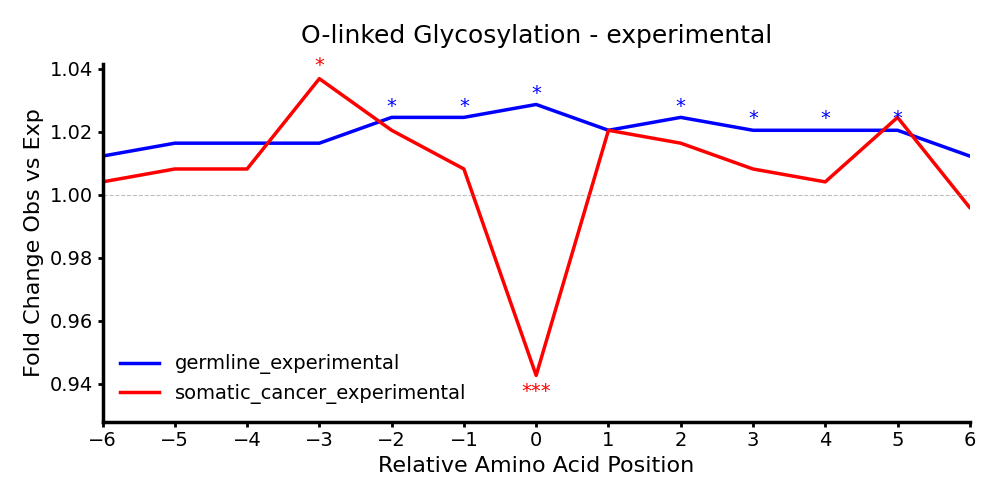

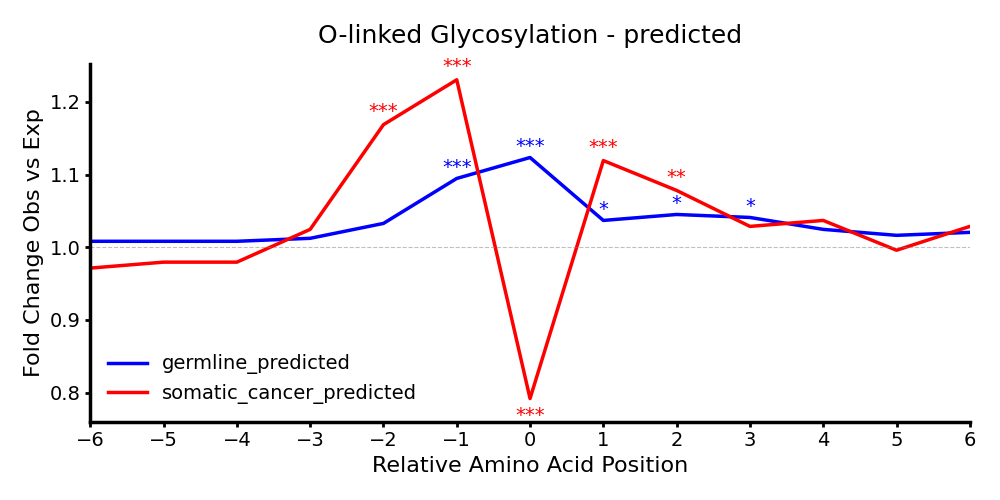

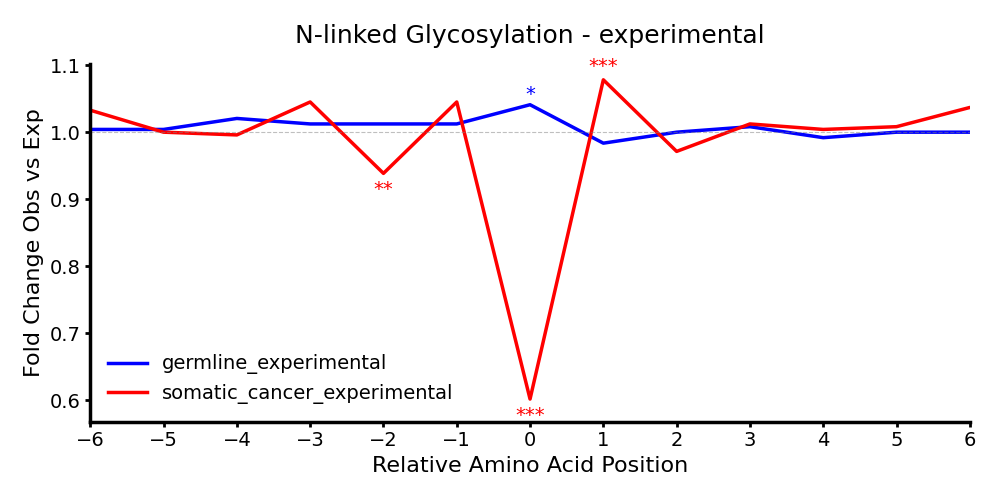

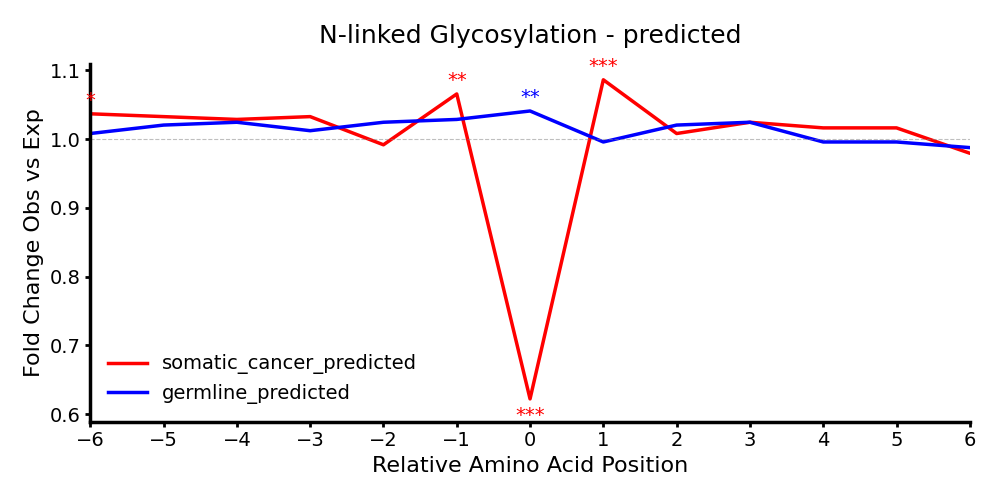

In [6]:
import os
import glob
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image

__version__ = "1.0"
__status__ = "Dev"

DATA_DIR  = "data"
PLOTS_DIR = "plots"


def load_map_dict(in_file):
    tmp_dict = {}
    with open(in_file, "r") as FR:
        f_list, idx = [], 0
        for line in FR:
            idx += 1
            row = line[1:-2].strip().split("\",\"")
            if idx == 1:
                f_list = row
            else:
                canon    = row[f_list.index("uniprot_canonical_ac")]
                site_pos = int(row[f_list.index("site_pos")])
                var_pos  = int(row[f_list.index("variant_pos")])
                rel_pos  = int(row[f_list.index("relative_pos")])
                cmb = "%s|%s|%s|%s" % (canon, site_pos, var_pos, rel_pos)
                tmp_dict[cmb] = True
    return tmp_dict


def load_binomial_results(in_file):
    p_dict = {}
    with open(in_file, "r") as FR:
        f_list, idx = [], 0
        for line in FR:
            idx += 1
            row = line.strip().strip('"').split('","')
            if idx == 1:
                f_list = row
            else:
                rel_pos = int(row[f_list.index("relative_pos")])
                # use the FDR-corrected p-value, per the step 3 methodology
                p_fdr = float(row[f_list.index("p_value_fdr")])
                p_dict[rel_pos] = p_fdr
    return p_dict


def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return ''


def generate_plot(glyco_type, site_type):

    gt = glyco_type.lower().replace("-", "_")
    print("\nGenerating plot for %s - %s" % (glyco_type, site_type))

    file_list = glob.glob(os.path.join(DATA_DIR, "mapping.human.%s.*_%s.csv" % (gt, site_type)))
    print("Files found for plotting:")
    for f in file_list:
        print("  %s" % f)

    if not file_list:
        print("No files found — skipping.")
        return

    out_doc = {}
    min_x, max_x = 10000, -1000
    for in_file in file_list:
        var_type = in_file.split(".")[-2]
        out_doc[var_type] = {"rel_pos": [], "count": [], "ratio": [], "fc": []}
        map_dict = load_map_dict(in_file)
        stat_dict = {}
        total = 0
        for cmb in map_dict:
            rel_pos = int(cmb.split("|")[-1])
            min_x = rel_pos if rel_pos < min_x else min_x
            max_x = rel_pos if rel_pos > max_x else max_x
            if rel_pos not in stat_dict:
                stat_dict[rel_pos] = 0
            stat_dict[rel_pos] += 1
            total += 1
        for rel_pos in sorted(stat_dict):
            count = stat_dict[rel_pos]
            ratio = round(float(count) / float(total), 4)
            out_doc[var_type]["rel_pos"].append(rel_pos)
            out_doc[var_type]["count"].append(count)
            out_doc[var_type]["ratio"].append(ratio)

    for var_type in out_doc:
        for rel_pos in out_doc[var_type]["rel_pos"]:
            idx = out_doc[var_type]["rel_pos"].index(rel_pos)
            own_ratio = out_doc[var_type]["ratio"][idx]
            others_sum = 0.0
            for i in range(0, len(out_doc[var_type]["ratio"])):
                if i == idx:
                    continue
                others_sum += out_doc[var_type]["ratio"][i]
            others_mean = round(others_sum / float(len(out_doc[var_type]["ratio"]) - 1), 4)
            fc = round(own_ratio / others_mean, 4)
            out_doc[var_type]["fc"].append(fc)

    out_file = os.path.join(PLOTS_DIR, "plotdata.human.%s.all_%s.json" % (gt, site_type))
    FW = open(out_file, "w")
    FW.write("%s\n" % (json.dumps(out_doc, indent=4)))
    FW.close()
    print("Plot data written: %s" % out_file)

    plt.figure(figsize=(10, 5))

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.rcParams.update({
        'font.size': 16,
        'axes.titlesize': 16,
        'axes.labelsize': 16,
        'xtick.labelsize': 18,
        'ytick.labelsize': 18,
        'legend.fontsize': 14
    })

    plt.rcParams['axes.linewidth'] = 2.5
    plt.rcParams['xtick.major.width'] = 2
    plt.rcParams['ytick.major.width'] = 2
    plt.rcParams['xtick.minor.width'] = 1.5
    plt.rcParams['ytick.minor.width'] = 1.5

    color_map = {
        "germline_predicted":          "blue",
        "germline_experimental":       "blue",
        "somatic_cancer_predicted":    "red",
        "somatic_cancer_experimental": "red",
    }

    for var_type in out_doc:
        x = out_doc[var_type]["rel_pos"]
        y = out_doc[var_type]["fc"]
        label = var_type.replace("_all_all_", "_").replace("_all_", "_")
        color = color_map.get(label, "black")
        plt.plot(x, y, label=label, linestyle='-', color=color, linewidth=2.5)

        binomial_file = os.path.join(DATA_DIR, "binomial_test.mapping.human.%s.%s.csv" % (gt, var_type))
        if os.path.exists(binomial_file):
            p_dict = load_binomial_results(binomial_file)
            for rel_pos, fc_val in zip(x, y):
                if rel_pos < -6 or rel_pos > 6:
                    continue
                if rel_pos in p_dict:
                    star = get_star(p_dict[rel_pos])
                    if star:
                        y_min, y_max = plt.ylim()
                        y_range = y_max - y_min
                        offset = -(y_range * 0.02) if fc_val < 1.0 else (y_range * 0.01)
                        va = 'top' if fc_val < 1.0 else 'bottom'
                        plt.text(rel_pos, fc_val + offset, star,
                                 ha='center', va=va, fontsize=14, color=color)
        else:
            print("Warning: no binomial results file found for %s" % var_type)

    plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    y_min, y_max = plt.ylim()
    plt.ylim(y_min - 0.01, y_max)

    plt.title("%s Glycosylation - %s" % (glyco_type, site_type), fontsize=18, pad=15)
    plt.xlabel("Relative Amino Acid Position", fontsize=16)
    plt.ylabel("Fold Change Obs vs Exp", fontsize=16)
    plt.xticks(np.arange(-6, 7, 1), fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim(-6, 6)
    plt.legend(loc='lower left', framealpha=0)
    plt.tight_layout()

    png_file = os.path.join(PLOTS_DIR, "plot.human.%s.all_%s.png" % (gt, site_type))
    plt.savefig(png_file)
    plt.close()
    print("Plot saved: %s" % png_file)


# automatically generate all 4 plots
os.makedirs(PLOTS_DIR, exist_ok=True)

plots = [
    ("O-linked", "experimental"),
    ("O-linked", "predicted"),
    ("N-linked", "experimental"),
    ("N-linked", "predicted"),
]

for glyco_type, site_type in plots:
    generate_plot(glyco_type, site_type)

print("\nAll 4 plots generated successfully.")

# ── Display all saved plots as a gallery ────────────────────────────────────
for glyco_type, site_type in plots:
    gt = glyco_type.lower().replace("-", "_")
    png_file = os.path.join(PLOTS_DIR, "plot.human.%s.all_%s.png" % (gt, site_type))
    if os.path.exists(png_file):
        display(Image(filename=png_file))
    else:
        print("Missing plot file, skipping display: %s" % png_file)